# Time evolution

In [1]:
using TensorOperations
using OMEinsum
using LinearAlgebra
using Plots

# Time evolution

This tutorial guides you in the implementation of the iTEBD invented by Vidal in 2005. We will follow once more G. Evenbly implementation. 

Beside going to the canonical form (that we have already seen yesterday)
the core of the game is to apply a two body gate, and then go back to the the MPS caonical form. 

The two body gate represents a short evolution step as seen in class today.

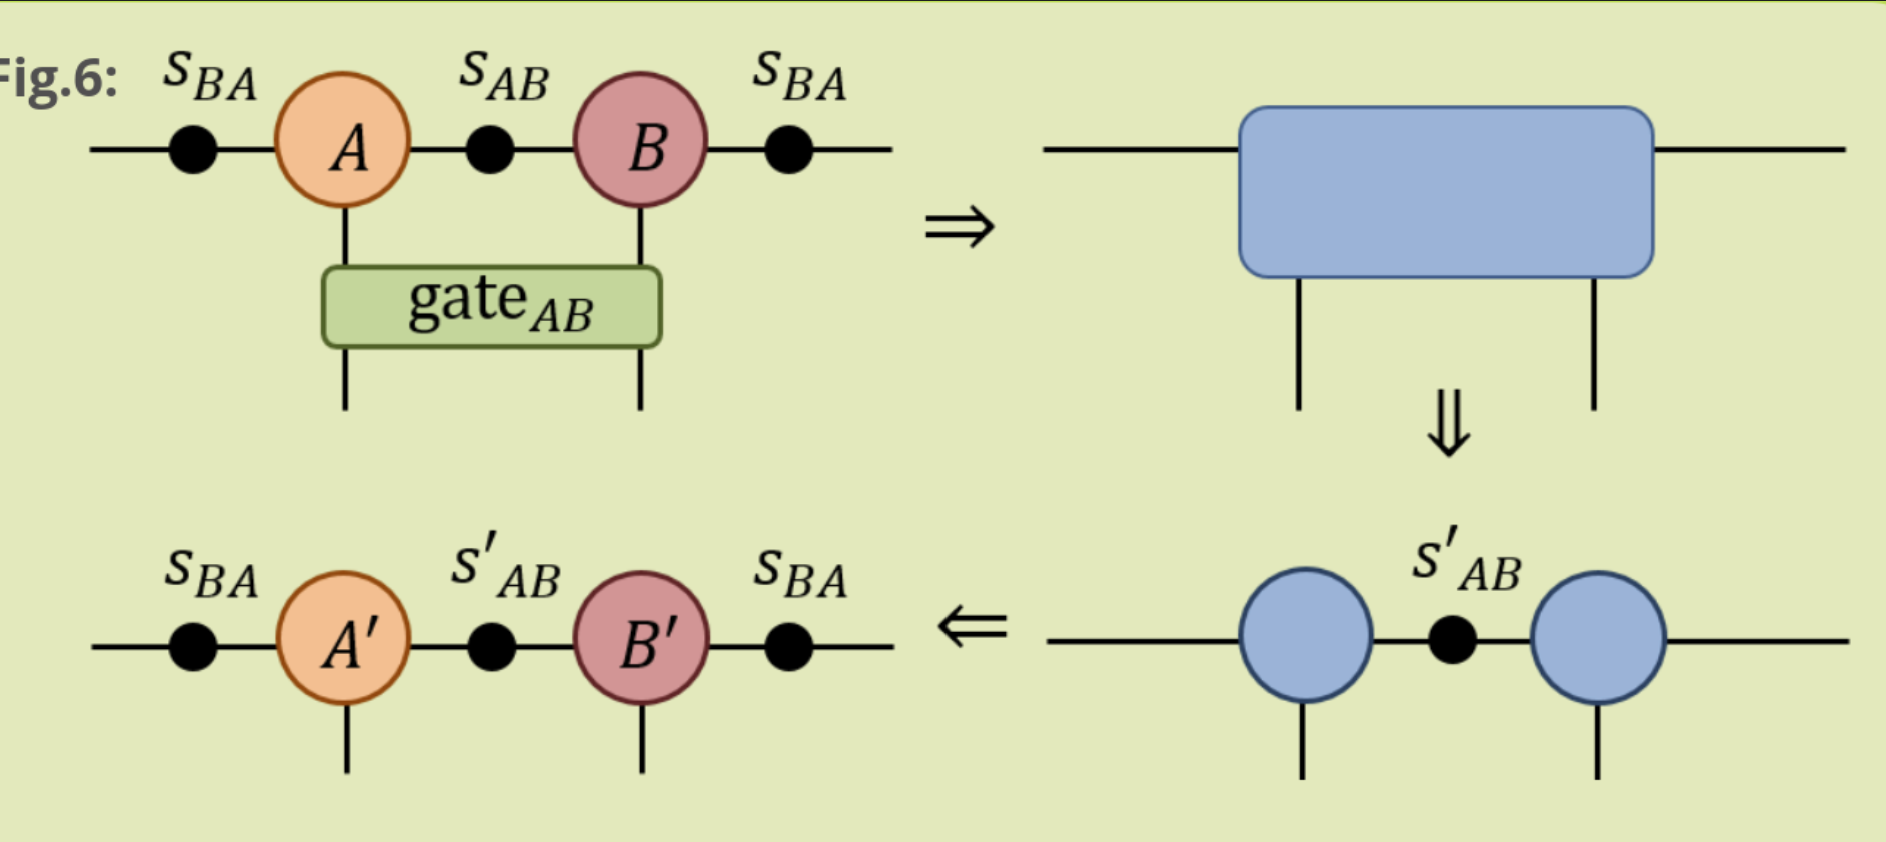
The MPS tensors are ordered left-center right

Assuming that the tensor network is in the canonical form the function that applies the gate is this

## Exercice 1
Complete the network contraction 

In [2]:
"""
apply_gate_MPS: Apply a gate to an MPS across and a A-B link. Truncate the MPS
back to some desired dimension chi.
"""
function apply_gate_MPS(gateAB,A,sAB,B,sBA,chi,stol=1e-7)

  # ensure singular values are above tolerance threshold
  sBA_trim = sBA.*(sBA .> stol) + stol.*(sBA .< stol);

  # contract gate into the MPS, then deompose composite tensor with SVD
  d = size(A,2);
  chiBA = size(sBA_trim,1);
  tensors = Any[diagm(0=>sBA_trim),A,diagm(0=>sAB),B,diagm(0=>sBA_trim),gateAB];
  connects = Any[[-1,1],[1,5,2],[2,4],[4,6,3],[3,-4],[-2,-3,5,6]];
  nshape = [d*chiBA,d*chiBA];
  F = svd(reshape(ncon(tensors,connects),nshape...));

  # truncate to reduced dimension
  chitemp = min(chi,length(F.S));
  utemp = reshape(F.U[:,1:chitemp],size(sBA_trim,1),d*chitemp);
  vhtemp = reshape((F.Vt[1:chitemp,:]),chitemp*d,size(sBA_trim,1))

  # remove environment weights to form new MPS tensors A and B
  A = reshape(diagm(0 => (1 ./sBA_trim))*utemp,chiBA,d,chitemp);
  B = reshape(vhtemp*diagm(0 => (1 ./sBA_trim)),chitemp,d,chiBA);

  # new weights
  sAB = F.S[1:chitemp]./sqrt(sum((F.S[1:chitemp]).^2));

  return A,sAB,B
end


apply_gate_MPS

### Exercise 2:
Compute the reduced density matrix from MPS assumed they are in canonical form.

In [3]:
"""
loc_density_MPS: compute the local reduced density matrices from an MPS
(assumend to be in canonical form).
"""
function loc_density_MPS(A,sAB,B,sBA)

  mAB = diagm(0 => sAB);
  mBA = diagm(0 => sBA);

  # contract MPS for local reduced density matrix (A-B)
  tensors = Any[diagm(0 => sBA.^2),A,conj(A),mAB,mAB,B,conj(B),diagm(0 =>sBA.^2)];
  connects = Any[[3,4],[3,-3,1],[4,-1,2],[1,7],[2,8],[7,-4,5],[8,-2,6],[5,6]];
  rhoAB = ncon(tensors,connects);

  # contract MPS for local reduced density matrix (B-A)
  tensors = Any[diagm(0 => sAB.^2),B,conj(B),mBA,mBA,A,conj(A),diagm(0 =>sAB.^2)];
  connects = Any[[3,4],[3,-3,1],[4,-1,2],[1,7],[2,8],[7,-4,5],[8,-2,6],[5,6]];
  rhoBA = ncon(tensors,connects);

  return rhoAB, rhoBA
end


loc_density_MPS

Now put everyhting together to simulate a quench for the Ising model starting from the ground state with $\lambda=\infty$ to the critical Hamiltonian with $\lambda=1$.

### Exercise 3

Modify the functions from G. Evenbly (in tensors.net) such that:
- Performs the quench discussed
- Returns a list of interesting quantities (the energy, the magnetization and the entanglement spectrum as function of time)
- Disable orthofonalization (we are using unitary gates)


In [4]:
"""
doTEBD(hamAB,hamBA,A,B,sAB,sBA,chi,tau; evotype = "imag", numiter = 1000,
  midsteps = 10, E0 = 0.0)
------------------------
by Glen Evenbly (c) for www.tensors.net, (v1.2) - last modified 06/2020
------------------------
Implementation of time evolution (real or imaginary) for MPS with 2-site
unit cell (A-B), based on TEBD algorithm. Nearest neighbor input
Hamiltonian is specified by 'hamAB, hamBA', while 'A' and 'B' are the MPS
tensors, 'sAB' and 'sBA' are the index weights. Maximum bond dimension
specified by 'chi', and timestep by 'tau'.

Optional arguments:
- `evotype="imag"`: real or imaginary time evolution ["real","imag"]
- `numiter::1000`: number of iterations to perform
- `midsteps::Int=10`: number of evolution steps between MPS re-orthogonalization
- `E0::Float=0.0`: specify exact ground energy (if known)
"""
function doTEBD(hamAB,hamBA,A,B,sAB,sBA,chi,tau,mag_AB; evotype = "imag",
  numiter = 1000, midsteps = 10, E0 = 0.0)

  # exponentiate Hamiltonian
  d = size(A,2);
  if evotype == "real"
    gateAB = reshape(exp(im*tau*reshape(hamAB,d^2,d^2)),d,d,d,d);
    gateBA = reshape(exp(im*tau*reshape(hamBA,d^2,d^2)),d,d,d,d);
  elseif evotype == "imag"
    gateAB = reshape(exp(-tau*reshape(hamAB,d^2,d^2)),d,d,d,d);
    gateBA = reshape(exp(-tau*reshape(hamBA,d^2,d^2)),d,d,d,d);
  end

  # initializr environment tensors
  sigBA = Matrix{Float64}(I,size(A,1),size(A,1)) ./size(A,1);
  muAB = Matrix{Float64}(I,size(A,3),size(A,3)) ./size(A,3);

  list_sAB = []
  list_energy = []
  list_mag = []

  for k = 0:numiter
    """ Do evolution of MPS through one time-step """
    if k < numiter
      # apply gate to A-B link
      A, sAB, B = apply_gate_MPS(gateAB,A,sAB,B,sBA,chi)
      # apply gate to B-A link
      B, sBA, A = apply_gate_MPS(gateBA,B,sBA,A,sAB,chi)


      push!(list_sAB,sAB)
    # compute 2-site local reduced density matrices
      rhoAB, rhoBA = loc_density_MPS(A, sAB, B, sBA)

      # evaluate the energy
      energyAB = ncon([hamAB, rhoAB], [[1, 2, 3, 4], [1, 2, 3, 4]])
      energyBA = ncon([hamBA, rhoBA], [[1, 2, 3, 4], [1, 2, 3, 4]])
      v_mag_AB = ncon([mag_AB, rhoAB], [[1, 2, 3, 4], [1, 2, 3, 4]])
      energy = 0.5 * (energyAB + energyBA)
      push!(list_energy,energy)
      push!(list_mag,v_mag_AB)
      rhoAB, rhoBA = loc_density_MPS(A, sAB, B, sBA)
    end
  end

  rhoAB, rhoBA = loc_density_MPS(A,sAB,B,sBA);
  return A, B, sAB, sBA, rhoAB, rhoBA,list_energy,list_sAB,list_mag
end

doTEBD

Remember the Ising model has the following Hamiltonian

\begin{equation}
    H = -\sum_i \left(\sigma_{x,i} \sigma_{x,i+1} + \lambda \sigma_{z,i}\right)
\end{equation}

We assume that the initial state is the ground state of $H$ with $\lambda=\infty$, i.e. $\psi_0 = \ket{\uparrow\uparrow\dots \uparrow}$ and then we evolve the state under the critical Hamiltonian $\lambda=1$.

In [5]:
""" Example 1: Ising model """

# set bond dimensions and simulation options
chi = 300 # bond dimension
tau = 0.01  # timestep
λ = 1.
numiter = 500 # number of timesteps
evotype = "real"  # real or imaginary time evolution
midsteps = 1000  # timesteps between MPS re-orthogonalization

# define Hamiltonian (Ising model)
sX = [0 1; 1 0];
sZ = [1 0; 0 -1];

hamAB = reshape(real(kron(sX, sX)) +λ*0.5*(
    real(kron(sZ, I(2))
            +kron(I(2),sZ))),(2,2,2,2))
hamBA = reshape(real(kron(sX, sX)) +λ*0.5*(
    real(kron(sZ, I(2))
            +kron(I(2),sZ))),(2,2,2,2))


# initialize tensors
d = size(hamAB,1)
sAB = ones(d) / sqrt(d)
sBA = ones(d) / sqrt(d)
A = zeros(d, d, d)
B = zeros(d, d, d)

A[1,1,1]=1.
B[1,1,1]=1.

mag_AB =reshape(0.5*(kron(sZ,I(2))+
               kron(I(2),sZ)),(d,d,d,d))

""" Real time evolution with TEBD """
# run TEBD routine


A, B, sAB, sBA, rhoAB, 
    rhoBA,list_ene,list_ent_spe,list_mag =doTEBD(hamAB,hamBA,A,B,sAB,sBA,chi,tau,mag_AB; evotype = evotype,
    numiter = numiter, midsteps = midsteps)
# continute running TEBD routine with reduced timestep and increased bond dim

# compare with exact results
energyMPS = real(0.5 * ncon([hamAB, rhoAB], [[1, 2, 3, 4], [1, 2, 3, 4]]) +
                    0.5 * ncon([hamBA, rhoBA], [[1, 2, 3, 4], [1, 2, 3, 4]]))

println("Final results => Bond dim: $(chi), Energy: $(energyMPS)")


Final results => Bond dim: 300, Energy: 0.9999597338079569


# Playaround

Produce plots for the following quantities:
- Energy error
- Magnetization evolution over time
- The evolution of the 10 values of entanglement spectrum $-\log(s_i)$
- The Von Neuman entropy


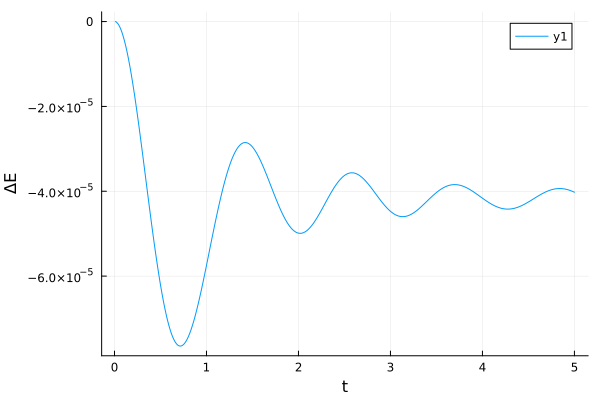

In [8]:
plot((tau:tau:tau*numiter), real(list_ene .-list_ene[1]))
xlabel!("t")
ylabel!("ΔE")

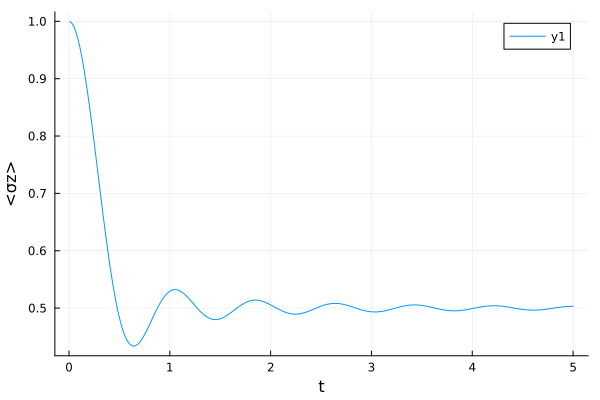

In [9]:
plot((tau:tau:tau*numiter), real(list_mag))
xlabel!("t")
ylabel!("<σz>")

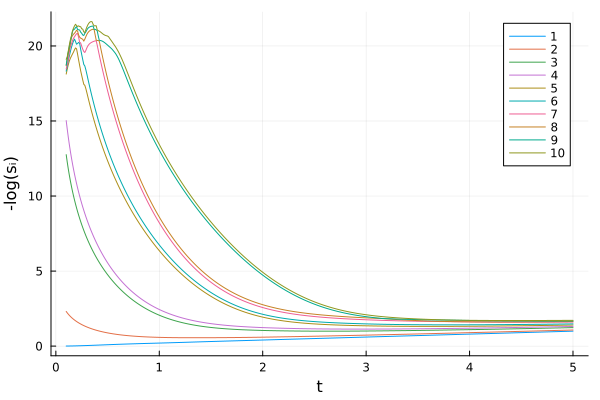

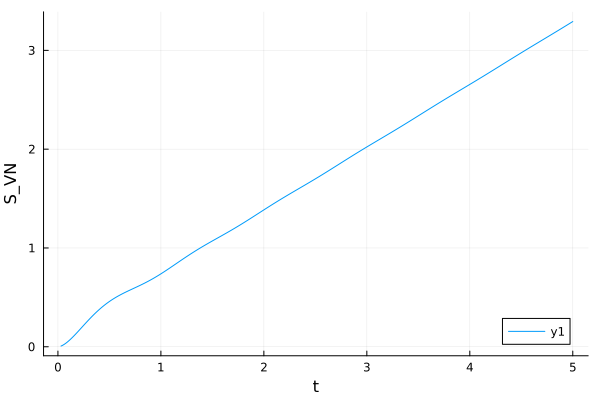

In [27]:
ents = []
spec_ents = zeros(numiter,10)
for i=1:numiter
    push!(ents, sum(-list_ent_spe[i].^2 .*log.(list_ent_spe[i].^2)))
    aux = min(10, length(list_ent_spe[i]))
    spec_ents[i,1:aux] = list_ent_spe[i][1:aux]
    spec_ents[i,aux+1:10] .= NaN
end

p1= plot()
for i=1:10
    plot!((tau:tau:tau*numiter)[10:end],-log.(spec_ents[10:end,i]), label = "$(i)")
end
xlabel!("t")
ylabel!("-log(sᵢ)")
display(p1)

plot((tau:tau:tau*numiter), ents)
xlabel!("t")
ylabel!("S_VN")
